In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
data = pd.read_csv("datainfo.csv")

In [55]:
data.head()

,phone_number,name,email,city,age,sex,married_status,job,income,religion,nationality
0,016-66389504,YdjRDqxJ,ydjrdqxj@example.com,Dhaka,56,Male,Divorced,Graphic Designer,136354,Other,Bangladeshi
1,018-30350691,ibNktb,ibnktb@example.com,Rajshahi,51,Female,Divorced,Project Manager,97533,Hinduism,Bangladeshi
2,018-46542610,fZhdlf,fzhdlf@example.com,Barisal,31,Female,Divorced,Accountant,121643,Islam,Bangladeshi
3,016-47460718,dFQgvjLr,dfqgvjlr@example.com,Chittagong,25,Male,Married,Accountant,112962,Other,Bangladeshi
4,017-17502595,qNyVnZ,qnyvnz@example.com,Khulna,22,Male,Single,Marketing Specialist,135689,Hinduism,Bangladeshi


In [56]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   phone_number    50000 non-null  object
 1   name            50000 non-null  object
 2   email           50000 non-null  object
 3   city            50000 non-null  object
 4   age             50000 non-null  int64 
 5   sex             50000 non-null  object
 6   married_status  50000 non-null  object
 7   job             50000 non-null  object
 8   income          50000 non-null  int64 
 9   religion        50000 non-null  object
 10  nationality     50000 non-null  object
dtypes: int64(2), object(9)
memory usage: 4.2+ MB


In [57]:
missing_values = data.isnull().sum()

print(missing_values)

phone_number      0
name              0
email             0
city              0
age               0
sex               0
married_status    0
job               0
income            0
religion          0
nationality       0
dtype: int64


<Axes: xlabel='income'>

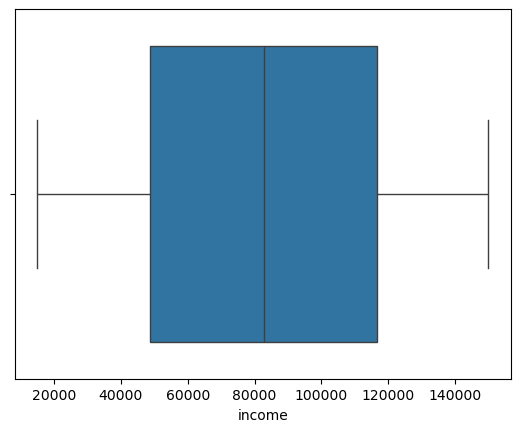

In [58]:
sns.boxplot(x = 'income' , data = data)

In [59]:
Q1 = data['income'].quantile(0.25)
Q2 = data['income'].quantile(0.75)

IQR = Q2 - Q1

print(IQR)

67965.25


In [60]:
cleaned_data = data[(data['income'] > Q1 - 1.5 * IQR) & (data['income'] < Q2 + 1.5 * IQR)]

print(cleaned_data)

       phone_number        name                   email        city  age  \
0      016-66389504    YdjRDqxJ    ydjrdqxj@example.com       Dhaka   56   
1      018-30350691      ibNktb      ibnktb@example.com    Rajshahi   51   
2      018-46542610      fZhdlf      fzhdlf@example.com     Barisal   31   
3      016-47460718    dFQgvjLr    dfqgvjlr@example.com  Chittagong   25   
4      017-17502595      qNyVnZ      qnyvnz@example.com      Khulna   22   
...             ...         ...                     ...         ...  ...   
49995  015-88712354      MrojIJ      mrojij@example.com     Barisal   56   
49996  017-07065331   dHiUPiLyx   dhiupilyx@example.com  Chittagong   58   
49997  019-94775091    yqqXOGuo    yqqxoguo@example.com    Rajshahi   28   
49998  015-38109742  ydtgLegxZt  ydtglegxzt@example.com       Dhaka   28   
49999  017-74511714   pGrBecuhu   pgrbecuhu@example.com     Barisal   41   

          sex married_status                   job  income  religion  \
0        Male  

<Axes: xlabel='income'>

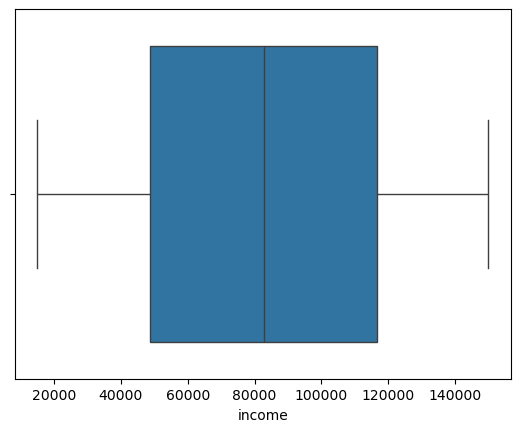

In [61]:
sns.boxplot(x = 'income' , data = cleaned_data)

In [62]:
lower_bound = 0
upper_bound = 100000

data['income'] = data['income'].apply(lambda x: lower_bound if x < lower_bound else (upper_bound if x > upper_bound else x))

<Axes: xlabel='income'>

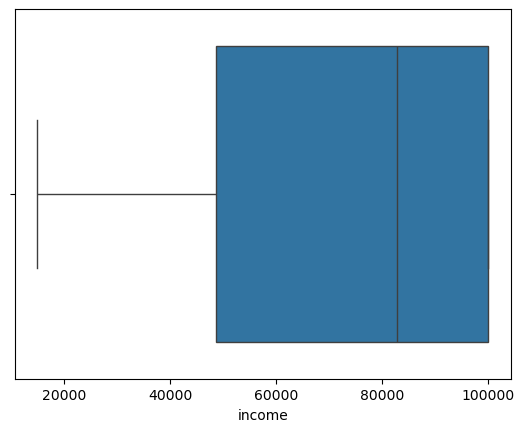

In [63]:
sns.boxplot(x = 'income' , data = data)

In [64]:
data['income'] = np.log(data['income'] + 1)

<Axes: xlabel='income'>

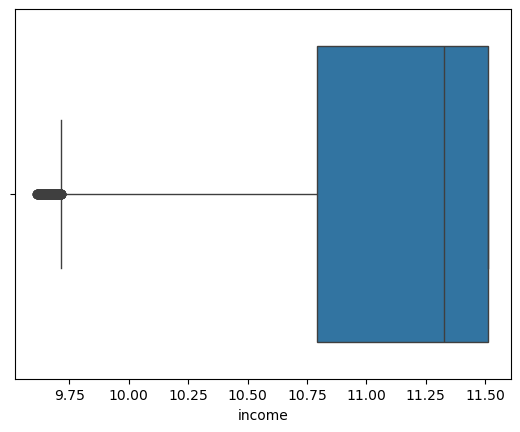

In [65]:
sns.boxplot(x = 'income' , data = data)

In [66]:
encoded_data = pd.get_dummies(data , columns = ['nationality'])
encoded_data.head()

,phone_number,name,email,city,age,sex,married_status,job,income,religion,nationality_Bangladeshi
0,016-66389504,YdjRDqxJ,ydjrdqxj@example.com,Dhaka,56,Male,Divorced,Graphic Designer,11.512935,Other,True
1,018-30350691,ibNktb,ibnktb@example.com,Rajshahi,51,Female,Divorced,Project Manager,11.487956,Hinduism,True
2,018-46542610,fZhdlf,fzhdlf@example.com,Barisal,31,Female,Divorced,Accountant,11.512935,Islam,True
3,016-47460718,dFQgvjLr,dfqgvjlr@example.com,Chittagong,25,Male,Married,Accountant,11.512935,Other,True
4,017-17502595,qNyVnZ,qnyvnz@example.com,Khulna,22,Male,Single,Marketing Specialist,11.512935,Hinduism,True


In [67]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   phone_number    50000 non-null  object 
 1   name            50000 non-null  object 
 2   email           50000 non-null  object 
 3   city            50000 non-null  object 
 4   age             50000 non-null  int64  
 5   sex             50000 non-null  object 
 6   married_status  50000 non-null  object 
 7   job             50000 non-null  object 
 8   income          50000 non-null  float64
 9   religion        50000 non-null  object 
 10  nationality     50000 non-null  object 
dtypes: float64(1), int64(1), object(9)
memory usage: 4.2+ MB


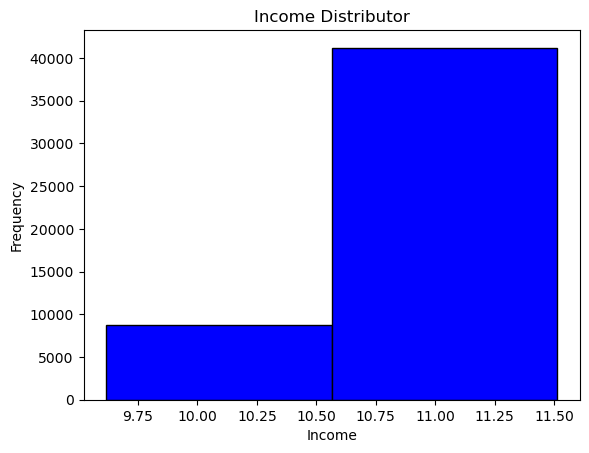

In [76]:
plt.hist(data['income'], bins = 2, color = 'blue', edgecolor = 'black')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.title('Income Distributor')
plt.show()

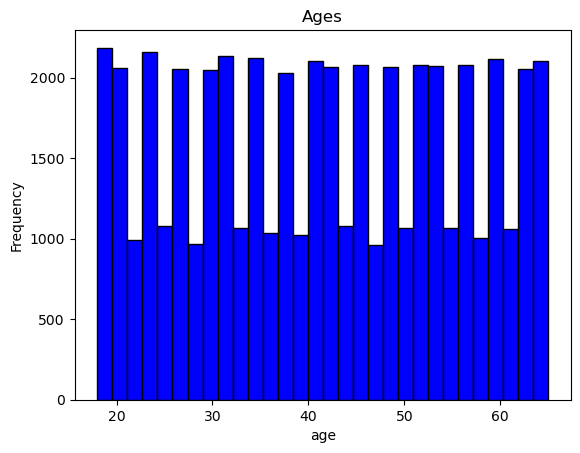

In [79]:
plt.hist(data['age'], bins = 30, color = 'blue', edgecolor = 'black')
plt.xlabel('age')
plt.ylabel('Frequency')
plt.title('Ages')
plt.show()

             age    income
age     1.000000 -0.004084
income -0.004084  1.000000


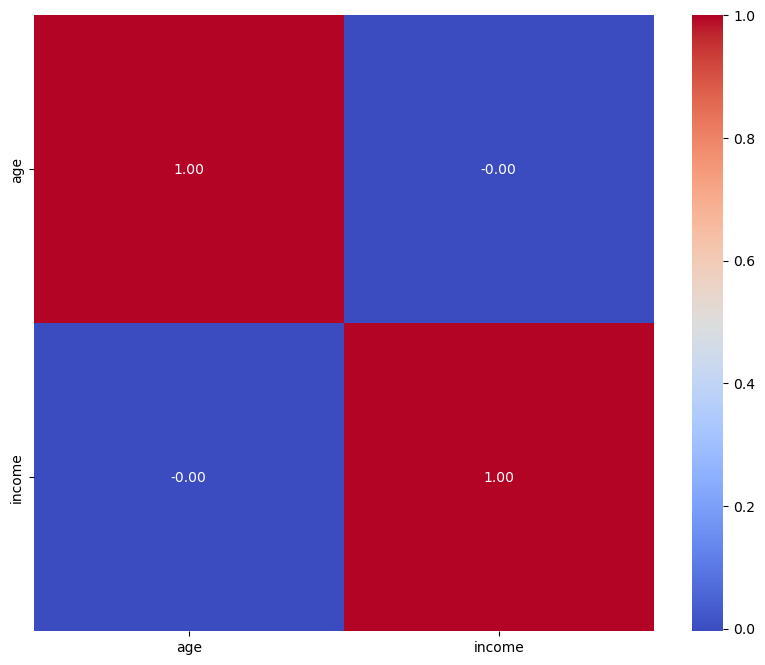

In [82]:
corr_matrix = data.corr(numeric_only = True)

print(corr_matrix)

plt.figure(figsize = (10,8))
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm', fmt = '0.2f')
plt.show()